In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error, mean_absolute_error
from arch import arch_model

import warnings
warnings.filterwarnings('ignore')

# Configuramos el estilo de las gráficas
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")


Nuestra hipótesis es: La animadversión hacia Charlie Kirk disminuye tras su muerte en septiembre

Para respaldar esta hipótesis vamos a usar el dataset de la entrega anterior, en donde usaremos sentiment_score (rango de 0-1 donde más cercano a 1 es peor) y score (número de likes).

In [ ]:
# nos aseguramos que el dataset esté ordenado por fecha
df = pd.read_csv('../../data/processed/charlie_kirk_comments_processed.csv', index_col="id", usecols=['id', 'date', 'score', 'sentiment_score'])
df.sort_values('date', inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8056 entries, 1 to 8056
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   date             8056 non-null   object 
 1   score            8056 non-null   int64  
 2   sentiment_score  8056 non-null   float64
dtypes: float64(1), int64(1), object(1)
memory usage: 251.8+ KB


In [56]:
# calculamos el sentimiento pondera por día con el score como peso, consiguiendo así un solo valor por día
df["weighted"] = df["sentiment_score"] * df["score"]

new_df = (
    df.groupby("date")
      .agg(weighted_mean=("weighted", "sum"),
           weight_sum=("score", "sum"))
)

new_df["sentiment_weighted"] = new_df["weighted_mean"] / new_df["weight_sum"]

new_df = new_df[["sentiment_weighted"]].reset_index()
new_df

,date,sentiment_weighted
0,2024-11-01,0.736521
1,2024-11-03,0.855872
2,2024-11-04,0.956509
3,2024-11-05,0.788400
4,2024-11-06,0.892660
...,...,...
201,2025-10-10,0.716459
202,2025-10-11,0.830101
203,2025-10-13,0.915636
204,2025-10-14,0.912955


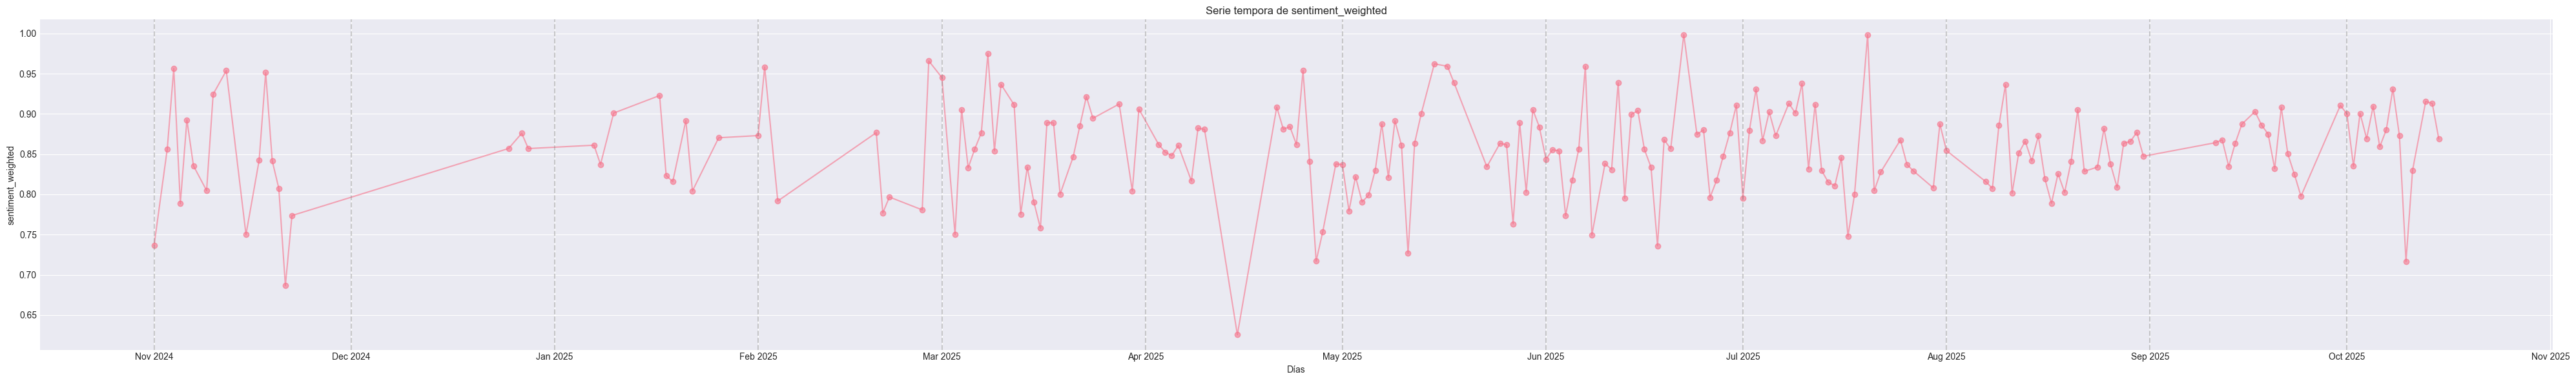

In [ ]:
# este es el gráfico resultante y es la serie con la que trabajaremos

new_df['date'] = pd.to_datetime(new_df['date'])

plt.figure(figsize=(40, 6))
plt.plot(new_df['date'], new_df['sentiment_weighted'], 
         label='sentiment_weighted', alpha=0.6, marker='o')

plt.title('Serie tempora de sentiment_weighted')
plt.xlabel("Días")
plt.ylabel("sentiment_weighted")

month_starts = new_df['date'].dt.to_period('M').drop_duplicates().dt.to_timestamp()

for d in month_starts:
    plt.axvline(x=d, color='gray', linestyle='--', alpha=0.4)

plt.gca().xaxis.set_major_locator(mdates.MonthLocator())
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.tight_layout()
plt.show()


* Explorar la evolución de los indicadores a lo largo del tiempo
* Identificar patrones relevantes (picos, tendencias, estacionalidad)

Para cumplir con estos puntos vamos a analizar las estadísticas de la serie y por periodos. Luego, analizaremos en mayor profundidad la serie haciendo su descomposición y usando la autocorrelación

In [58]:
# mostramos algunos datos estadísticos básicos de la serie temporal
new_df.set_index('date', inplace=True)
new_df = new_df.sort_index()

print("ESTADÍSTICAS DESCRIPTIVAS")
print(new_df['sentiment_weighted'].describe())

print(f"\nRango de sentimiento: [{new_df['sentiment_weighted'].min():.4f}, {new_df['sentiment_weighted'].max():.4f}]")
print(f"Coeficiente de variación: {(new_df['sentiment_weighted'].std() / new_df['sentiment_weighted'].mean()):.4f}")


ESTADÍSTICAS DESCRIPTIVAS
count    206.000000
mean       0.854469
std        0.057999
min        0.625470
25%        0.819807
50%        0.856814
75%        0.889090
max        0.998613
Name: sentiment_weighted, dtype: float64

Rango de sentimiento: [0.6255, 0.9986]
Coeficiente de variación: 0.0679


ANÁLISIS POR PERÍODOS

Estadísticas semanal:


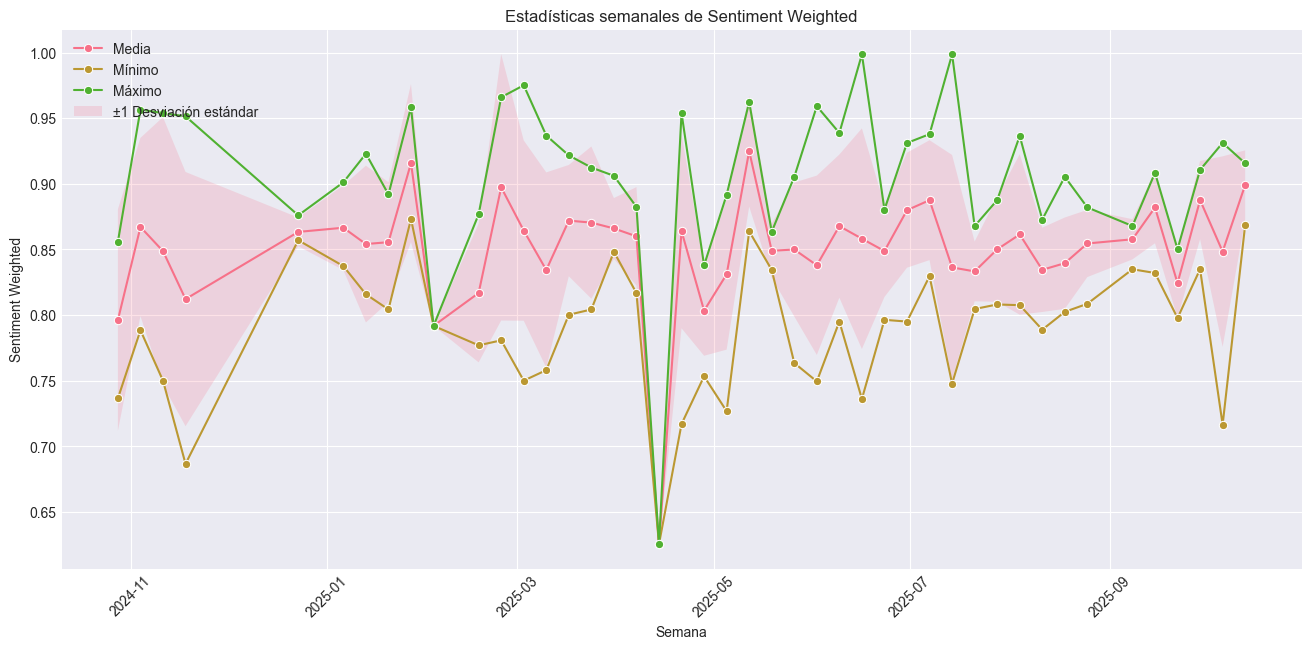

In [59]:
# exploramos las estadísticas por períodos (semanal)

print("ANÁLISIS POR PERÍODOS")
new_df['semana'] = new_df.index.to_period('W').start_time
stats_semanal = new_df.groupby('semana')['sentiment_weighted'].agg([
    ('media', 'mean'),
    ('desv_std', 'std'),
    ('mínimo', 'min'),
    ('máximo', 'max'),
]).fillna(0)
print("\nEstadísticas semanal:")

plt.figure(figsize=(16,7))
sns.lineplot(data=stats_semanal, x=stats_semanal.index, y='media', marker='o', label='Media')
sns.lineplot(data=stats_semanal, x=stats_semanal.index, y='mínimo', marker='o', label='Mínimo')
sns.lineplot(data=stats_semanal, x=stats_semanal.index, y='máximo', marker='o', label='Máximo')

plt.fill_between(
    stats_semanal.index,
    stats_semanal['media'] - stats_semanal['desv_std'],
    stats_semanal['media'] + stats_semanal['desv_std'],
    alpha=0.2,
    label='±1 Desviación estándar'
)

plt.title('Estadísticas semanales de Sentiment Weighted')
plt.xlabel('Semana')
plt.ylabel('Sentiment Weighted')
plt.xticks(rotation=45)
plt.grid(True)
plt.legend(loc='upper left')
plt.show()


DESCOMPOSICIÓN DE LA SERIE TEMPORAL


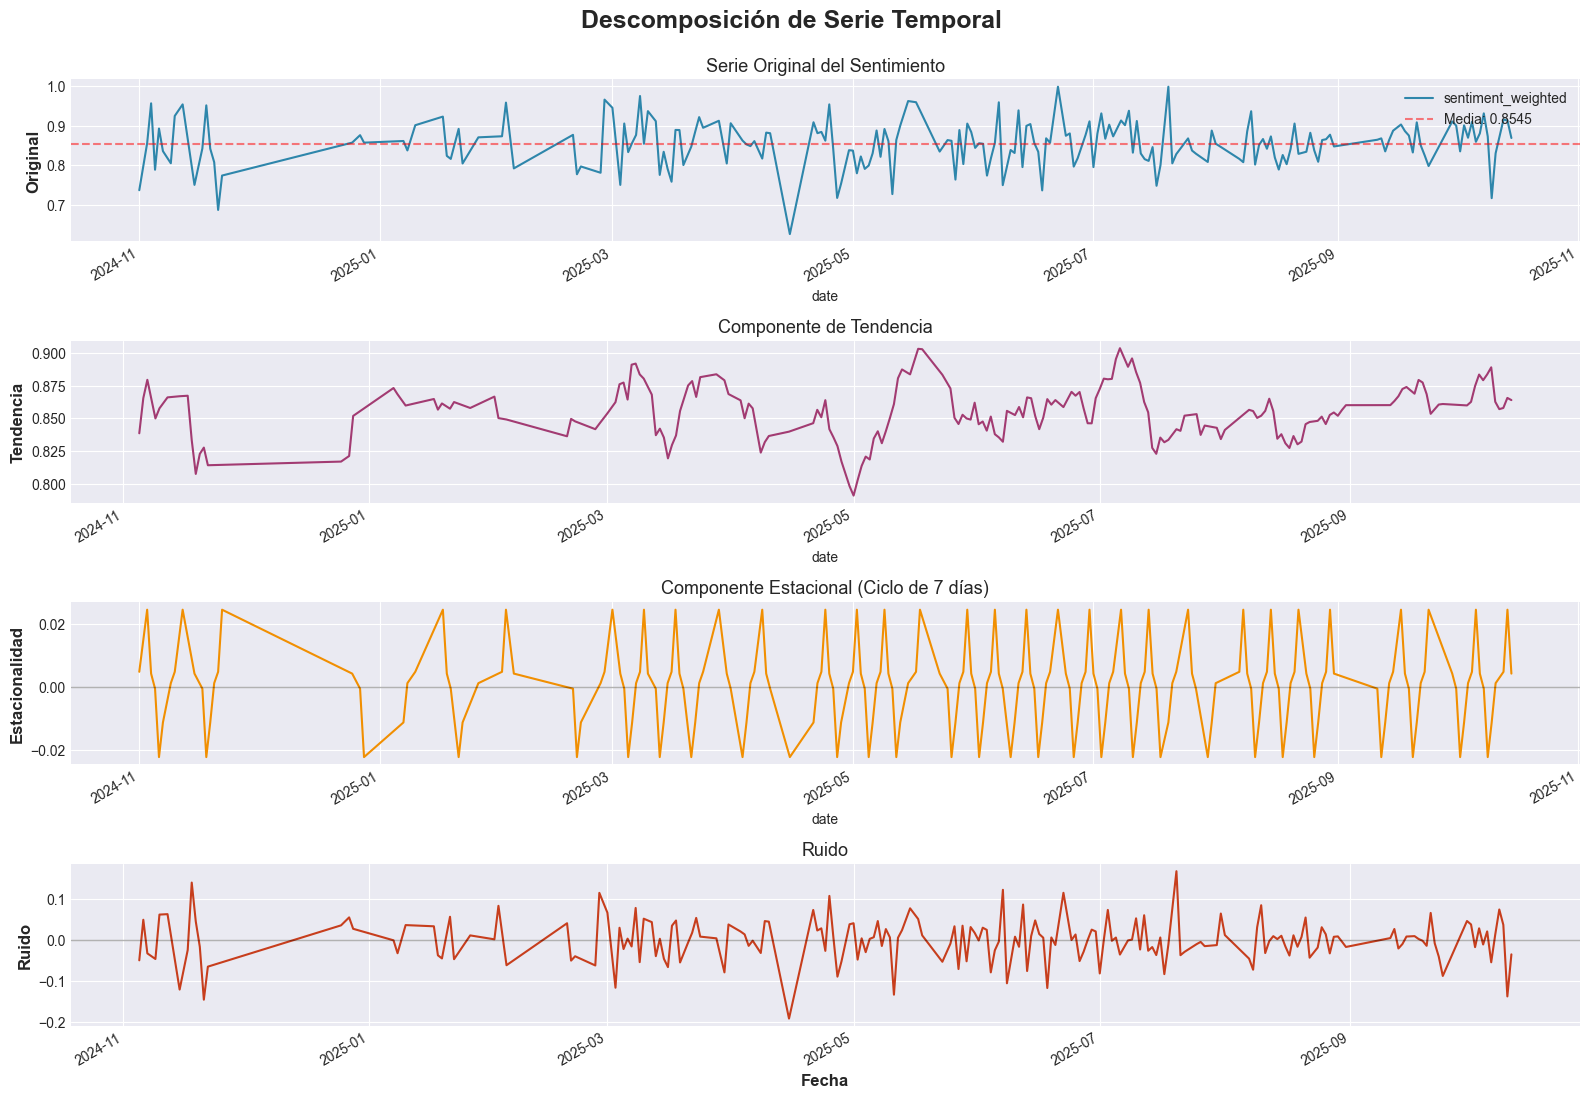


ANÁLISIS DE TENDENCIA:
  Valor inicial: 0.8386
  Valor final: 0.8640
  Cambio absoluto: +0.0254
  Cambio porcentual: +3.02%
  Interpretación: Tendencia CRECIENTE

ANÁLISIS DE ESTACIONALIDAD:
  Amplitud estacional: 0.0135
  Rango estacional: [-0.0224, 0.0245]


In [60]:
# análisis de descomposición de la serie temporal, usaremos período semanal (7 días)

print("DESCOMPOSICIÓN DE LA SERIE TEMPORAL")
period = 7
decomposition = seasonal_decompose(new_df['sentiment_weighted'], model='additive', period=period)

fig, axes = plt.subplots(4, 1, figsize=(16, 11))
fig.suptitle('Descomposición de Serie Temporal ', fontsize=18, fontweight='bold', y=0.995)

# original
new_df['sentiment_weighted'].plot(ax=axes[0], color='#2E86AB', linewidth=1.5)
axes[0].set_ylabel('Original', fontsize=12, fontweight='bold')
axes[0].set_title('Serie Original del Sentimiento', fontsize=13)
axes[0].axhline(y=new_df['sentiment_weighted'].mean(), color='red', linestyle='--', 
                alpha=0.5, linewidth=1.5, label=f'Media: {new_df["sentiment_weighted"].mean():.4f}')
axes[0].legend(loc='upper right')

# tendencia
decomposition.trend.plot(ax=axes[1], color='#A23B72', linewidth=1.5)
axes[1].set_ylabel('Tendencia', fontsize=12, fontweight='bold')
axes[1].set_title('Componente de Tendencia', fontsize=13)

# Estacionalidad
decomposition.seasonal.plot(ax=axes[2], color='#F18F01', linewidth=1.5)
axes[2].set_ylabel('Estacionalidad', fontsize=12, fontweight='bold')
axes[2].set_title(f'Componente Estacional (Ciclo de {period} días)', fontsize=13)
axes[2].axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)

# Ruido
decomposition.resid.plot(ax=axes[3], color='#C73E1D', linewidth=1.5)
axes[3].set_ylabel('Ruido', fontsize=12, fontweight='bold')
axes[3].set_title('Ruido', fontsize=13)
axes[3].set_xlabel('Fecha', fontsize=12, fontweight='bold')
axes[3].axhline(y=0, color='black', linestyle='-', alpha=0.3, linewidth=1)

plt.tight_layout()
plt.savefig('visualizaciones/1_descomposicion_temporal.png', dpi=300, bbox_inches='tight')
plt.show()

# Análisis cuantitativo de la tendencia
tendencia_limpia = decomposition.trend.dropna()
tendencia_inicio = tendencia_limpia.iloc[0]
tendencia_fin = tendencia_limpia.iloc[-1]
tendencia_cambio = tendencia_fin - tendencia_inicio
tendencia_cambio_pct = (tendencia_cambio / tendencia_inicio) * 100

print(f"\nANÁLISIS DE TENDENCIA:")
print(f"  Valor inicial: {tendencia_inicio:.4f}")
print(f"  Valor final: {tendencia_fin:.4f}")
print(f"  Cambio absoluto: {tendencia_cambio:+.4f}")
print(f"  Cambio porcentual: {tendencia_cambio_pct:+.2f}%")
print(f"  Interpretación: Tendencia {'CRECIENTE' if tendencia_cambio > 0 else 'DECRECIENTE'}")

print(f"\nANÁLISIS DE ESTACIONALIDAD:")
print(f"  Amplitud estacional: {decomposition.seasonal.std():.4f}")
print(f"  Rango estacional: [{decomposition.seasonal.min():.4f}, {decomposition.seasonal.max():.4f}]")

# Pico máximo (~1.0): Julio 2025 - Sentimiento muy negativo
# Pico alto (~0.95-0.98): Noviembre 2024, Marzo 2025, Octubre 2025
# Valle profundo (~0.65): Mayo 2025 - Anomalía significativa
# Valle (~0.70-0.75): Diciembre 2024, Octubre 2025 (final)
# Alta volatilidad: fluctuaciones frecuentes y pronunciadas

# Componente de tendencia ligeramente creciente con fluctuaciones. Es decir, tendencia general neutro con volatilidad alta. No
# hay tendencia clara de largo plazo, y múltiples ciclos de subida y bajada. 

# Estacionalidad débil pero regular, con un patrón semanal visible cada 7 días. Sin embargo, la amplitud es muy pequeña 
# (~2% del valor medio) y no es estadísticamente significativa.

# En resumen, existe un leve patrón día-de-la-semana, pero NO domina la serie. Como veremos en ACF/PACF, este patrón no es estadísticamente significativo


ANÁLISIS DE AUTOCORRELACIÓN


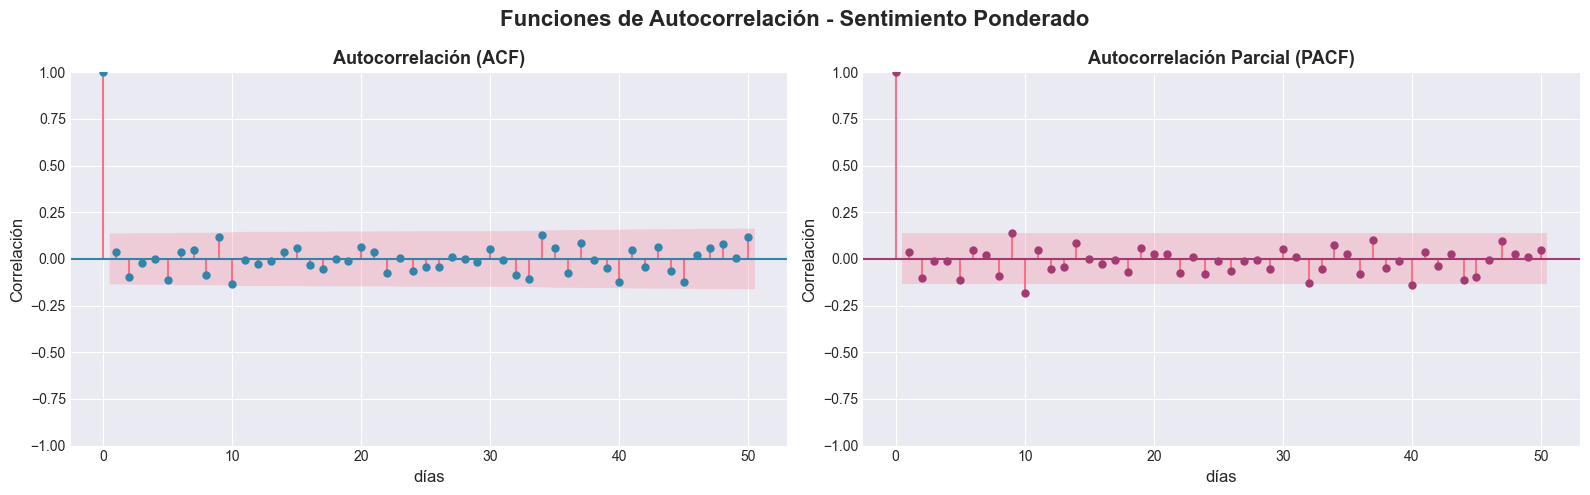

In [61]:
# análisis de autocorrelación y autocorrelación parcial

print("ANÁLISIS DE AUTOCORRELACIÓN")
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Funciones de Autocorrelación - Sentimiento Ponderado', 
             fontsize=16, fontweight='bold')

# ACF
plot_acf(new_df['sentiment_weighted'], lags=50, ax=axes[0], color='#2E86AB')
axes[0].set_title('Autocorrelación (ACF)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('días', fontsize=12)
axes[0].set_ylabel('Correlación', fontsize=12)

# PACF
plot_pacf(new_df['sentiment_weighted'], lags=50, ax=axes[1], color='#A23B72')
axes[1].set_title('Autocorrelación Parcial (PACF)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('días', fontsize=12)
axes[1].set_ylabel('Correlación', fontsize=12)

plt.tight_layout()
plt.savefig('visualizaciones/2_autocorrelacion.png', dpi=300, bbox_inches='tight')
plt.show()

# Si ACF decae gradualmente la serie tiene tendencia, si PACF corta abruptamente en lag k es indicativo de un modelo AR(k) apropiado, y si
# hay picos significativos, indica estacionalidad.
# Con los resultados obtenidos, podemos deducir que la serie es bastante aleatoria dado que no hay picos significativos en ACF ni PACF.

* Aplicar al menos  una técnica de series temporales vista en clase (ej. SARIMAX, suavizado exponencial, o técnicas basadas en RNN).
* Utilizar métricas de ajuste o precisión cuando proceda (ej. RMSE, MAE). 

Hemos aplicado SARIMAX y suavizado exponencial. Además hemos mostado una visualización para comparar su rendimietno. Para evaluar dicho rendimiento se ha hecho uso de las dos métricas propuestas.

Por propuesta del profesor, al poder ser muy interesando en una serie temporal tan aleatorio, se ha implementado GARCH también.

In [62]:
# modelado SARIMAX(1,1,1)(1,1,1)[7]

print("MODELADO SARIMAX")

# División train/test (70% entrenamiento, 30% prueba)
train_size = int(len(new_df) * 0.7)
train = new_df['sentiment_weighted'][:train_size]
test = new_df['sentiment_weighted'][train_size:]

try:
    model = SARIMAX(train, 
                    order=(1, 1, 1),             
                    seasonal_order=(1, 1, 1, 7),   
                    enforce_stationarity=False,
                    enforce_invertibility=False)
    
    results = model.fit(disp=False, maxiter=200)
    print(f"Criterios de información del modelo:")
    # Cuanto menor sea mejor estos valores
    print(f"  AIC: {results.aic:.2f}")
    print(f"  BIC: {results.bic:.2f}")
    
    pred_train = results.fittedvalues
    pred_test = results.forecast(steps=len(test))
    pred_test.index = test.index
    
    # Evaluamos el rendimiento del modelo
    rmse_train = np.sqrt(mean_squared_error(train[1:], pred_train[1:]))
    mae_train = mean_absolute_error(train[1:], pred_train[1:])
    rmse_test = np.sqrt(mean_squared_error(test, pred_test))
    mae_test = mean_absolute_error(test, pred_test)
    
    print(f"MÉTRICAS DE EVALUACIÓN SARIMAX")
    print(f"{'='*50}")
    print(f"{'Conjunto':<15} {'RMSE':<12} {'MAE':<12}")
    print(f"{'-'*50}")
    print(f"{'Entrenamiento':<15} {rmse_train:<12.4f} {mae_train:<12.4f}")
    print(f"{'Prueba':<15} {rmse_test:<12.4f} {mae_test:<12.4f}")
    
    # Predicción futura (próximos mes)
    forecast_steps = 30
    forecast = results.forecast(steps=forecast_steps)
    forecast_index = pd.date_range(start=new_df.index[-1] + pd.Timedelta(days=1), 
                                   periods=forecast_steps, freq='D')
    forecast.index = forecast_index
    
    print(f"\nPredicción generada para {forecast_steps} días futuros")
    print(f"  Sentimiento promedio predicho: {forecast.mean():.4f}")
    
    sarimax_success = True
    
except Exception as e:
    print(f"\nError en SARIMAX: {e}")
    sarimax_success = False
    results = None

# Con los resultados obtenidos, podemos deducir que el modelo SARIMAX ha sido ajustado correctamente, dando valores AIC y BIC bastantes bajos. 
# Además, las métricas de MAE y RMSE también son muy buenas.

MODELADO SARIMAX
Criterios de información del modelo:
  AIC: -323.82
  BIC: -309.60
MÉTRICAS DE EVALUACIÓN SARIMAX
Conjunto        RMSE         MAE         
--------------------------------------------------
Entrenamiento   0.0808       0.0594      
Prueba          0.0460       0.0346      

Predicción generada para 30 días futuros
  Sentimiento promedio predicho: 0.8557


In [63]:
# Holt-Winters

print("SUAVIZADO EXPONENCIAL (Holt-Winters)")
try:
    hw_model = ExponentialSmoothing(train, seasonal_periods=7, trend='add', seasonal='add', damped_trend=True)
    hw_fit = hw_model.fit(optimized=True)
    
    # Predecimos en el conjunto de prueba
    hw_pred = hw_fit.forecast(steps=len(test))
    hw_pred.index = test.index
    
    # Métricas de evaluación
    hw_rmse = np.sqrt(mean_squared_error(test, hw_pred))
    hw_mae = mean_absolute_error(test, hw_pred)

    print(f"MÉTRICAS DE EVALUACIÓN HOLT-WINTERS")
    print(f"  RMSE: {hw_rmse:.4f}")
    print(f"  MAE:  {hw_mae:.4f}")
    
    hw_success = True
    
except Exception as e:
    print(f"\nError en Holt-Winters: {e}")
    hw_success = False
    hw_fit = None

# conseguimos unos resultados básicamente idénticos a los del SARIMAX, por lo que ambos modelos son válidos.

SUAVIZADO EXPONENCIAL (Holt-Winters)
MÉTRICAS DE EVALUACIÓN HOLT-WINTERS
  RMSE: 0.0461
  MAE:  0.0349


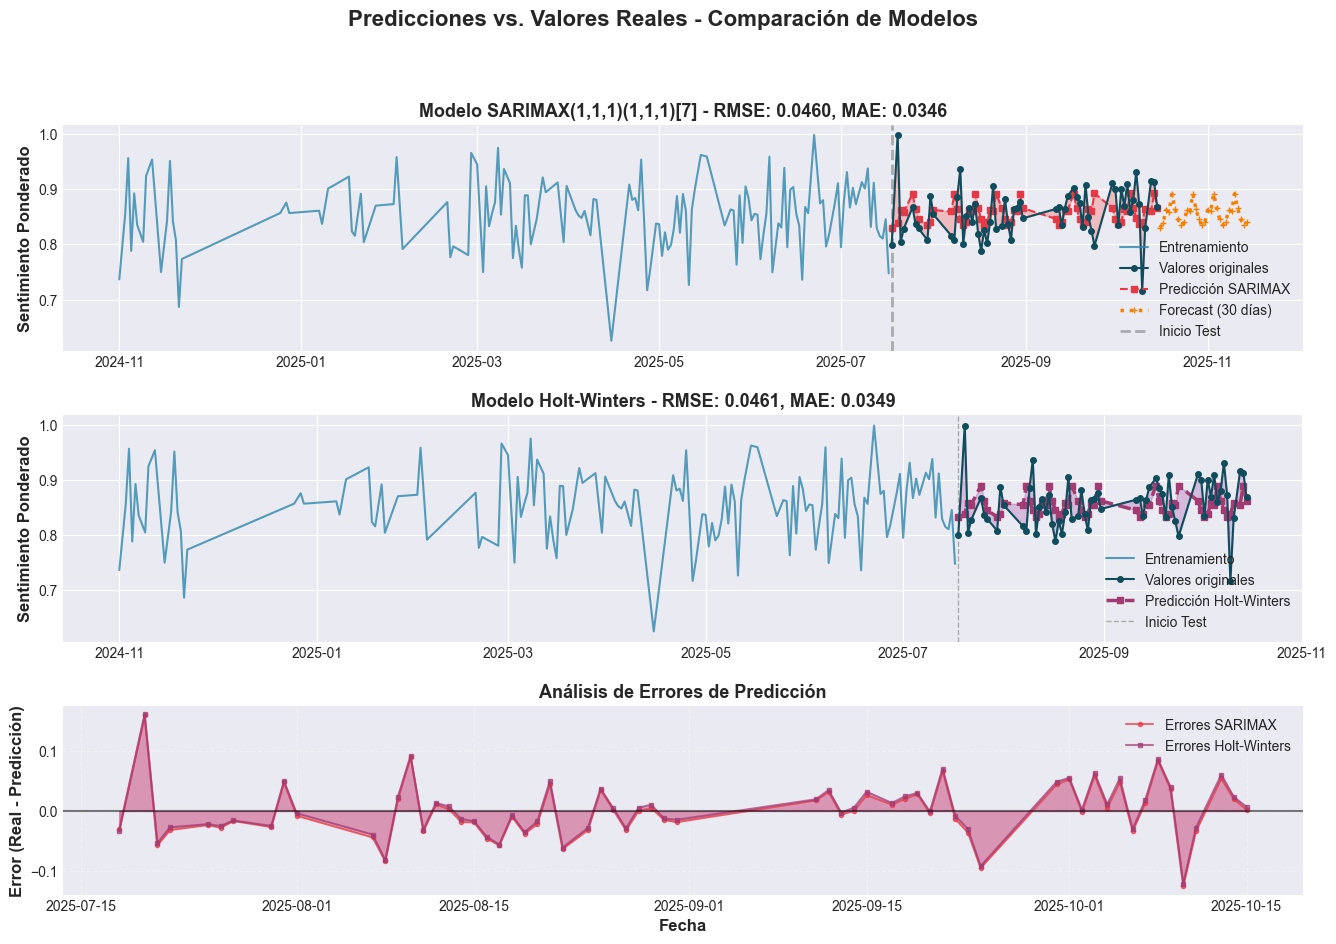

In [ ]:
# comparamos visualmente ambos modelos 

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 1, height_ratios=[1.2, 1.2, 1], hspace=0.3)

# SARIMAX
if sarimax_success:
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(train.index, train, label='Entrenamiento', color='#2E86AB', 
             linewidth=1.5, alpha=0.8)
    ax1.plot(test.index, test, label='Valores originales', color='#0F4C5C', 
            linewidth=1.5, marker='o', markersize=4, zorder=5)
    ax1.plot(test.index, pred_test, label='Predicción SARIMAX', 
            color='#E63946', linewidth=1.5, linestyle='--', marker='s', 
            markersize=4, zorder=4)
    ax1.plot(forecast_index, forecast, label=f'Forecast ({forecast_steps} días)', 
            color='#F77F00', linewidth=2.5, linestyle=':', marker='+', 
            markersize=4, zorder=3)
    ax1.axvline(x=test.index[0], color='gray', linestyle='--', alpha=0.6, 
                linewidth=2, label='Inicio Test')
    ax1.fill_between(test.index, test, pred_test, alpha=0.2, color='red')
    ax1.set_title(f'Modelo SARIMAX(1,1,1)(1,1,1)[7] - RMSE: {rmse_test:.4f}, MAE: {mae_test:.4f}', 
                 fontsize=13, fontweight='bold')
    ax1.set_ylabel('Sentimiento Ponderado', fontsize=12, fontweight='bold')
    ax1.legend(loc='best', fontsize=10, framealpha=0.9)

# Holt-Winters
if hw_success:
    ax2 = fig.add_subplot(gs[1])
    ax2.plot(train.index, train, label='Entrenamiento', color='#2E86AB', 
             linewidth=1.5, alpha=0.8)
    ax2.plot(test.index, test, label='Valores originales', color='#0F4C5C', 
            linewidth=1.5, marker='o', markersize=4, zorder=5)
    ax2.plot(test.index, hw_pred, label='Predicción Holt-Winters', 
            color='#A23B72', linewidth=2.5, linestyle='--', marker='s', 
            markersize=4, zorder=4)
    ax2.axvline(x=test.index[0], color='gray', linestyle='--', alpha=0.6, 
                linewidth=1, label='Inicio Test')
    ax2.fill_between(test.index, test, hw_pred, alpha=0.2, color='purple')
    ax2.set_title(f'Modelo Holt-Winters - RMSE: {hw_rmse:.4f}, MAE: {hw_mae:.4f}', 
                 fontsize=13, fontweight='bold')
    ax2.set_ylabel('Sentimiento Ponderado', fontsize=12, fontweight='bold')
    ax2.legend(loc='best', fontsize=10, framealpha=0.9)

# Comparación de errores
if sarimax_success and hw_success:
    ax3 = fig.add_subplot(gs[2])
    
    errores_sarimax = test - pred_test
    errores_hw = test - hw_pred
    
    ax3.plot(test.index, errores_sarimax, label='Errores SARIMAX', 
            color='#E63946', linewidth=1.5, marker='o', markersize=3, alpha=0.7)
    ax3.plot(test.index, errores_hw, label='Errores Holt-Winters', 
            color='#A23B72', linewidth=1.5, marker='s', markersize=3, alpha=0.7)
    ax3.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    ax3.fill_between(test.index, 0, errores_sarimax, alpha=0.2, color='red')
    ax3.fill_between(test.index, 0, errores_hw, alpha=0.2, color='purple')
    ax3.set_title('Análisis de Errores de Predicción', fontsize=13, fontweight='bold')
    ax3.set_xlabel('Fecha', fontsize=12, fontweight='bold')
    ax3.set_ylabel('Error (Real - Predicción)', fontsize=12, fontweight='bold')
    ax3.legend(loc='best', fontsize=10, framealpha=0.9)
    ax3.grid(True, alpha=0.3, linestyle='--')

fig.suptitle('Predicciones vs. Valores Reales - Comparación de Modelos', 
             fontsize=16, fontweight='bold', y=0.995)
plt.savefig('visualizaciones/3_predicciones_comparativas.png', dpi=300, bbox_inches='tight')
plt.show()

MODELADO GARCH
Criterios de información del modelo:
  AIC: -334.68
  BIC: -322.83


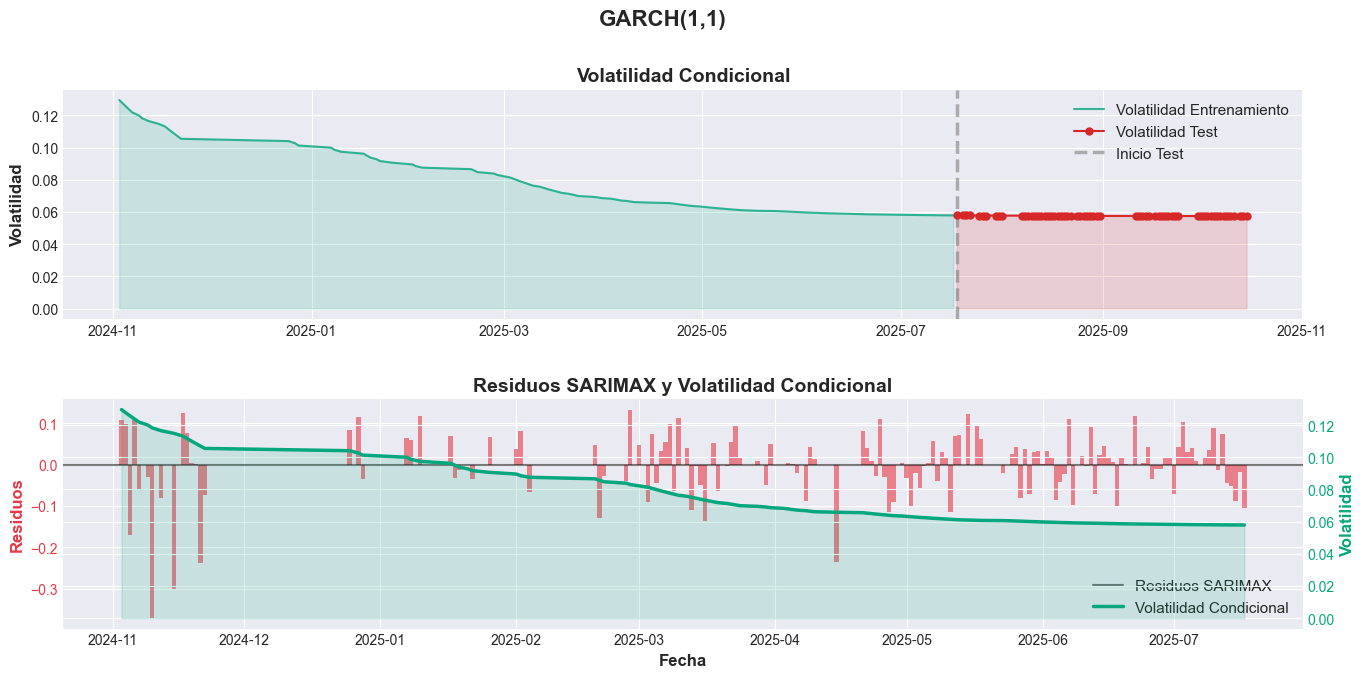


RESUMEN ESTADÍSTICO DE VOLATILIDAD
Volatilidad Media Train        0.0735      
Volatilidad Media Test         0.0576      
Volatilidad Máxima Test        0.0579      
Volatilidad Mínima Test        0.0575      
Desviación Std Test            0.0001      
Rango Volatilidad              0.0004      


In [64]:
# modelado GARCH(1,1) sobre los residuos del SARIMAX

print("MODELADO GARCH")
try:
    # Calculamos los residuos del modelo SARIMAX
    residuos = (train - results.fittedvalues[1:]).dropna()
    
    # Ajustamos modelo GARCH(1,1)
    garch_model = arch_model(residuos, vol='Garch', p=1, q=1, rescale=False)
    garch_fit = garch_model.fit(disp='off', show_warning=False)
    
    print(f"Criterios de información del modelo:")
    print(f"  AIC: {garch_fit.aic:.2f}")
    print(f"  BIC: {garch_fit.bic:.2f}")

    # Pronóstico de volatilidad y volatilidad en el train
    garch_forecast = garch_fit.forecast(horizon=len(test))
    volatilidad_test = np.sqrt(garch_forecast.variance.values[-1, :])
    volatilidad_train = garch_fit.conditional_volatility
    
    garch_success = True
    
except Exception as e:
    print(f"\nError en GARCH: {e}")
    garch_success = False
    volatilidad_train = None
    volatilidad_test = None

if garch_success:
    fig = plt.figure(figsize=(16, 7))
    gs = fig.add_gridspec(2, 1, height_ratios=[1.3, 1.3], hspace=0.35)

    # Volatilidad en Entrenamiento y Test
    ax1 = fig.add_subplot(gs[0])
    ax1.plot(volatilidad_train.index, volatilidad_train, label='Volatilidad Entrenamiento', 
            color='#06A77D', linewidth=1.5, alpha=0.8)
    ax1.fill_between(volatilidad_train.index, volatilidad_train, alpha=0.15, color='#06A77D')
    vol_test_index = test.index
    ax1.plot(vol_test_index, volatilidad_test, label='Volatilidad Test', 
            color='#D62828', linewidth=1.5, marker='o', markersize=5, zorder=5)
    ax1.fill_between(vol_test_index, volatilidad_test, alpha=0.15, color='#D62828')
    
    ax1.axvline(x=test.index[0], color='gray', linestyle='--', alpha=0.6, 
                linewidth=2.5, label='Inicio Test')
    
    ax1.set_title('Volatilidad Condicional', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Volatilidad', fontsize=12, fontweight='bold')
    ax1.legend(loc='best', fontsize=11, framealpha=0.95)

    # Residuos y su Volatilidad
    ax2 = fig.add_subplot(gs[1])
    ax2.bar(residuos.index, residuos, label='Residuos SARIMAX', 
            color='#E63946', alpha=0.6, width=1)
    ax2_twin = ax2.twinx()
    ax2_twin.plot(volatilidad_train.index, volatilidad_train, label='Volatilidad Condicional', 
                  color='#06A77D', linewidth=2.5, zorder=5)
    ax2_twin.fill_between(volatilidad_train.index, volatilidad_train, 
                          alpha=0.15, color='#06A77D')
    ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5, linewidth=1.5)
    
    ax2.set_title('Residuos SARIMAX y Volatilidad Condicional', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Fecha', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Residuos', fontsize=12, fontweight='bold', color='#E63946')
    ax2_twin.set_ylabel('Volatilidad', fontsize=12, fontweight='bold', color='#06A77D')
    ax2.tick_params(axis='y', labelcolor='#E63946')
    ax2_twin.tick_params(axis='y', labelcolor='#06A77D')
    
    lines_res = ax2.get_lines() + ax2_twin.get_lines()
    ax2.legend(lines_res, ['Residuos SARIMAX', 'Volatilidad Condicional'], 
               loc='best', fontsize=11, framealpha=0.95)

    fig.suptitle('GARCH(1,1)', fontsize=16, fontweight='bold', y=0.995)
    plt.savefig('visualizaciones/4_volatilidad_garch.png', dpi=300, bbox_inches='tight')
    plt.show()

print(f"\nRESUMEN ESTADÍSTICO DE VOLATILIDAD")
if garch_success:
    vol_mean_train = volatilidad_train.mean()
    vol_mean_test = volatilidad_test.mean()
    vol_max_test = volatilidad_test.max()
    vol_min_test = volatilidad_test.min()
    vol_std_test = volatilidad_test.std()
    
    print(f"{'Volatilidad Media Train':<30} {vol_mean_train:<12.4f}")
    print(f"{'Volatilidad Media Test':<30} {vol_mean_test:<12.4f}")
    print(f"{'Volatilidad Máxima Test':<30} {vol_max_test:<12.4f}")
    print(f"{'Volatilidad Mínima Test':<30} {vol_min_test:<12.4f}")
    print(f"{'Desviación Std Test':<30} {vol_std_test:<12.4f}")
    print(f"{'Rango Volatilidad':<30} {vol_max_test - vol_min_test:<12.4f}")


# Conseguimos unos buenos valores de AIC y BIC en el modelo GARCH(1,1), indicando un buen ajuste a los residuos del modelo SARIMAX.
# En la visualización, se muestra un claro decaimiento de la volatilidad, pesando de un riesgo alto (~0.12) a uno menor (~0.06). 
# En la volatilidad del conjunto de test obtenemos una horizontal, que se valida con la std de 0.0001 y un rango de 0.0004. 
# Esto significa que el riesgo se ha estabilizado.

# Además, vemos como el GARCH(1,1) es apropiado para modelar la volatilidad de los residuos del SARIMAX, ya que captura bien las 
# variaciones en la magnitud de los errores a lo largo del tiempo.

* Opcional:  aplicar  técnicas  adicionales  como  detección  de  anomalías, comparación de periodos o predicción de valores futuros.

Hemos hecho la detección de anomalías

DETECCIÓN DE ANOMALÍAS

Configuración de detección:
  Ventana móvil: 7 días
  Umbral: ±2 desviaciones estándar (~95% confianza)

Resultados:
  Anomalías detectadas: 2
  Porcentaje del total: 0.97%

  Top 5 anomalías:
    2025-04-15 → Valor: 0.6255 | Esperado: 0.8399 | Tipo: BAJA
    2025-10-10 → Valor: 0.7165 | Esperado: 0.8656 | Tipo: BAJA


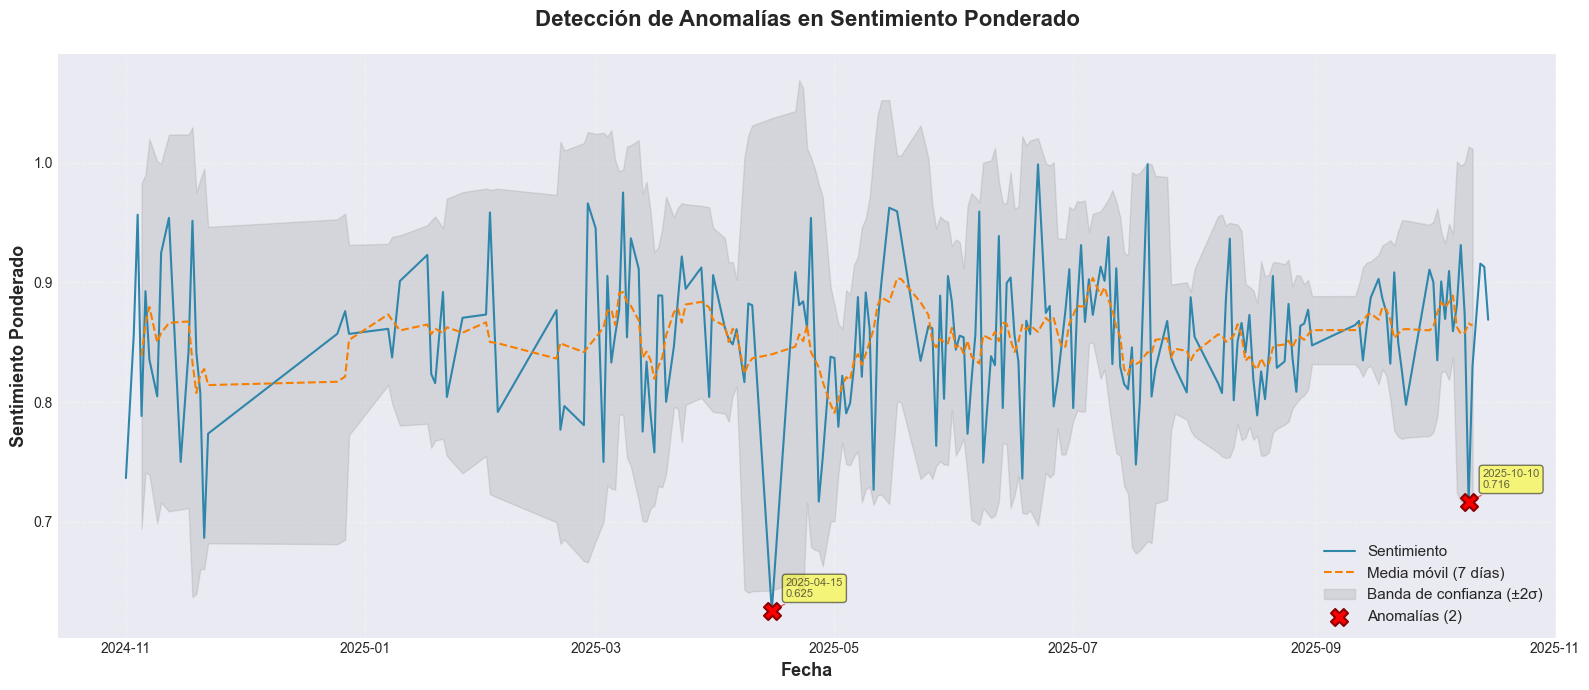

In [65]:
# detección de anomalías mediante media móvil y desviación estándar

print("DETECCIÓN DE ANOMALÍAS")
window = 7
df_anomaly = new_df.copy()
df_anomaly['rolling_mean'] = df_anomaly['sentiment_weighted'].rolling(window=window, center=True).mean()
df_anomaly['rolling_std'] = df_anomaly['sentiment_weighted'].rolling(window=window, center=True).std()

# Bandas de confianza (±2 desviaciones estándar = ~95% de los datos)
df_anomaly['upper_bound'] = df_anomaly['rolling_mean'] + (2 * df_anomaly['rolling_std'])
df_anomaly['lower_bound'] = df_anomaly['rolling_mean'] - (2 * df_anomaly['rolling_std'])

# Identificar anomalías
df_anomaly['anomaly'] = ((df_anomaly['sentiment_weighted'] > df_anomaly['upper_bound']) | 
                         (df_anomaly['sentiment_weighted'] < df_anomaly['lower_bound']))

anomalias = df_anomaly[df_anomaly['anomaly'] == True]
n_anomalias = len(anomalias)
pct_anomalias = (n_anomalias / len(new_df)) * 100

print(f"\nConfiguración de detección:")
print(f"  Ventana móvil: {window} días")
print(f"  Umbral: ±2 desviaciones estándar (~95% confianza)")

print(f"\nResultados:")
print(f"  Anomalías detectadas: {n_anomalias}")
print(f"  Porcentaje del total: {pct_anomalias:.2f}%")

if n_anomalias > 0:
    print(f"\n  Top 5 anomalías:")
    anomalias_sorted = anomalias.copy()
    anomalias_sorted['desviacion'] = abs(anomalias_sorted['sentiment_weighted'] - 
                                         anomalias_sorted['rolling_mean'])
    top_anomalias = anomalias_sorted.nlargest(5, 'desviacion')
    
    for idx, row in top_anomalias.iterrows():
        tipo = "ALTA" if row['sentiment_weighted'] > row['upper_bound'] else "BAJA"
        print(f"    {idx.date()} → Valor: {row['sentiment_weighted']:.4f} | "
              f"Esperado: {row['rolling_mean']:.4f} | Tipo: {tipo}")

fig, ax = plt.subplots(figsize=(16, 7))

# Serie principal
ax.plot(new_df.index, new_df['sentiment_weighted'], label='Sentimiento', 
        color='#2E86AB', linewidth=1.5, zorder=2)

# Media móvil
ax.plot(df_anomaly.index, df_anomaly['rolling_mean'], 
        label=f'Media móvil ({window} días)', 
        color='#F77F00', linewidth=1.5, linestyle='--', zorder=3)

# Bandas de confianza
ax.fill_between(df_anomaly.index, 
                df_anomaly['lower_bound'], 
                df_anomaly['upper_bound'], 
                alpha=0.2, color='gray', 
                label='Banda de confianza (±2σ)', zorder=1)

# Marcar anomalías
if n_anomalias > 0:
    ax.scatter(anomalias.index, anomalias['sentiment_weighted'], 
              color='red', s=150, marker='X', zorder=5, 
              label=f'Anomalías ({n_anomalias})', edgecolors='darkred', linewidths=1.5)

ax.set_title('Detección de Anomalías en Sentimiento Ponderado', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Fecha', fontsize=13, fontweight='bold')
ax.set_ylabel('Sentimiento Ponderado', fontsize=13, fontweight='bold')
ax.legend(loc='best', fontsize=11, framealpha=0.95)
ax.grid(True, alpha=0.3, linestyle='--')

if n_anomalias > 0 and n_anomalias <= 10:
    for idx, row in anomalias.iterrows():
        ax.annotate(f'{idx.date()}\n{row["sentiment_weighted"]:.3f}',
                   xy=(idx, row['sentiment_weighted']),
                   xytext=(10, 10), textcoords='offset points',
                   fontsize=8, alpha=0.7,
                   bbox=dict(boxstyle='round,pad=0.3', facecolor='yellow', alpha=0.5),
                   arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', 
                                 color='red', alpha=0.6))

plt.tight_layout()
plt.savefig('visualizaciones/5_deteccion_anomalias.png', dpi=300, bbox_inches='tight')
plt.show()

# La serie de sentimiento ponderado sigue mayormente un comportamiento estable y cercano a la normalidad, con solo un par
# de valores aislados fuera de lo esperado.

* Indicar explícitamente si los resultados apoyan o refutan la hipótesis.

Los resultados refutan la hipótesis planteada. Aunque se observa una disminución temporal de la animadversión a principios de octubre, este efecto:

1. Ocurre con un desfase de 2-3 semanas respecto al evento (principios-mediados de septiembre), lo cual cuestiona la relación causal directa
2. No se sostiene en el tiempo
3. Es consistente con la alta variabilidad general de la serie 

En definitiva, la muerte de Charlie Kirk no produjo un cambio estructural significativo en el sentimiento. La variabilidad observada post-septiembre 
es consistente con las fluctuaciones aleatorias previas, sin evidencia de un efecto permanente sobre la animadversión.

Todo los pasos realizados se encuentran más detallados en analysis.md.